# The answer was right. Was the path?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/agent-trajectory-eval/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/agent-trajectory-eval/demo.ipynb)

A refund agent is scored on its final answer. This notebook enumerates every trajectory a declared agent
can produce, and measures - exactly - how often a right answer sits on a broken path, and what the usual
reference-match modes (strict, unordered, superset) see instead.

1. The task and the spec
2. Calibration - exact enumeration vs raw simulation
3. Five scorers, two agent versions
4. The prompt change, as each scorer reports it
5. Try your own

## The engine

Extracted from `trajectory.py` at build time, character for character. The agent makes a few discrete
choices (which reads, in what order, an extra search, act before reading, retry the refund, mangle the
order id). `enumerate_runs` lists all 512 combinations with their probabilities; every scorer then runs on
the real step list of each one.

In [1]:
from __future__ import annotations

import itertools
from collections import Counter
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

P_ELIG = 0.7


ORDER = "A17"


WRONG = "A71"


PLANS = ("lookup>policy", "policy>lookup", "lookup only", "no reads")


PLAN_STEPS = {"lookup>policy": ("lookup_order", "check_policy"), "policy>lookup": ("check_policy", "lookup_order"),
              "lookup only": ("lookup_order",), "no reads": ()}


AGENTS: Dict[str, Dict[str, object]] = {
    "v1 careful": {"plan": (0.60, 0.30, 0.07, 0.03), "kb": 0.35, "rash": 0.03, "dup": 0.03, "badarg": 0.02,
                   "misread": 0.02},
    "v2 fewer calls": {"plan": (0.45, 0.15, 0.25, 0.15), "kb": 0.10, "rash": 0.10, "dup": 0.03, "badarg": 0.02,
                       "misread": 0.02},
}


SCORERS = ("outcome", "strict", "unordered", "superset", "outcome+superset")


INVARIANTS = ("unsupported decision", "acted before reading", "duplicate action", "wrong argument",
              "wrong action")


MC_REPS = 200_000


SEED = 189


Step = Tuple[str, Optional[str]]


def reference(eligible: bool) -> List[str]:
    return ["lookup_order", "check_policy"] + (["issue_refund"] if eligible else [])


def build(eligible: bool, plan: str, kb: bool, rash: bool, guess_yes: bool, misread: bool, dup: bool,
          badarg: bool) -> Tuple[List[Step], bool]:
    """One trajectory and whether its final answer is right.

    A rash agent decides before reading (a guess, and any refund goes first). A careful agent that read the
    policy decides correctly unless it misreads; one that never read the policy guesses. A refund issued
    without a lookup can only carry an invented order id.
    """
    reads = PLAN_STEPS[plan]
    informed = "check_policy" in reads and not rash
    decide_yes = (eligible != misread) if informed else guess_yes
    looked = "lookup_order" in reads and not rash
    arg = WRONG if (badarg or not looked) else ORDER
    refunds: List[Step] = [("issue_refund", arg)] * ((2 if dup else 1) if decide_yes else 0)
    steps: List[Step] = [("search_kb", None)] if kb else []
    read_steps: List[Step] = [(s, ORDER if s == "lookup_order" else None) for s in reads]
    steps += (refunds + read_steps) if rash else (read_steps + refunds)
    return steps, decide_yes == eligible


def violations(steps: Sequence[Step], eligible: bool) -> List[str]:
    """The declared spec of a valid path. Ground truth by construction - the point is what cheaper scorers miss."""
    names = [s for s, _ in steps]
    out = []
    if not {"lookup_order", "check_policy"} <= set(names):
        out.append("unsupported decision")
    seen: set = set()
    looked: Optional[str] = None
    for s, a in steps:
        if s == "issue_refund":
            if not {"lookup_order", "check_policy"} <= seen and "acted before reading" not in out:
                out.append("acted before reading")
            if a != looked and "wrong argument" not in out:
                out.append("wrong argument")
        if s == "lookup_order":
            looked = a
        seen.add(s)
    if names.count("issue_refund") > 1:
        out.append("duplicate action")
    if ("issue_refund" in names) != eligible:
        out.append("wrong action")
    return out


def score(steps: Sequence[Step], eligible: bool, correct: bool) -> Dict[str, bool]:
    names = [s for s, _ in steps]
    ref = reference(eligible)
    have, want = Counter(names), Counter(ref)
    strict = names == ref
    sup = all(have[k] >= v for k, v in want.items())
    return {"outcome": correct, "strict": strict, "unordered": have == want, "superset": sup,
            "outcome+superset": correct and sup}


def enumerate_runs(agent: Dict[str, object]) -> List[Dict[str, object]]:
    """Every (task, choice) combination with its probability. Choices that cannot matter are still enumerated."""
    runs = []
    for elig, pi, kb, rash, gy, mis, dup, bad in itertools.product(
            (True, False), range(4), (True, False), (True, False), (True, False), (True, False), (True, False),
            (True, False)):
        p = P_ELIG if elig else 1 - P_ELIG
        p *= agent["plan"][pi]
        for flag, q in ((kb, agent["kb"]), (rash, agent["rash"]), (gy, P_ELIG), (mis, agent["misread"]),
                        (dup, agent["dup"]), (bad, agent["badarg"])):
            p *= q if flag else 1 - q
        steps, correct = build(elig, PLANS[pi], kb, rash, gy, mis, dup, bad)
        v = violations(steps, elig)
        runs.append({"p": p, "eligible": elig, "steps": steps, "correct": correct, "violations": v,
                     "good": correct and not v, "scores": score(steps, elig, correct)})
    return runs


def summarise(runs: Sequence[Dict[str, object]]) -> Dict[str, object]:
    pg = sum(r["p"] for r in runs if r["good"])
    out: Dict[str, object] = {"p_good": pg, "p_correct": sum(r["p"] for r in runs if r["correct"]),
                              "calls": sum(r["p"] * len(r["steps"]) for r in runs), "scorers": {}}
    for s in SCORERS:
        pp = sum(r["p"] for r in runs if r["scores"][s])
        pass_bad = sum(r["p"] for r in runs if r["scores"][s] and not r["good"])
        fail_good = sum(r["p"] for r in runs if not r["scores"][s] and r["good"])
        out["scorers"][s] = {"reported": pp, "false_pass": pass_bad / (1 - pg), "false_fail": fail_good / pg,
                             "bad_among_passes": pass_bad / pp if pp else 0.0}
    out["hidden_by_outcome"] = {k: sum(r["p"] for r in runs if r["correct"] and k in r["violations"])
                                for k in INVARIANTS}
    return out


def evaluate() -> Dict[str, Dict[str, object]]:
    return {name: summarise(enumerate_runs(a)) for name, a in AGENTS.items()}


def simulate(agent: Dict[str, object], reps: int = MC_REPS, seed: int = SEED) -> Dict[str, float]:
    """Raw draws, step by step, through the same build/violations/score code. Checks the enumeration."""
    rng = np.random.default_rng(seed)
    elig = rng.random(reps) < P_ELIG
    plan = rng.choice(4, size=reps, p=agent["plan"])
    flags = {k: rng.random(reps) < q for k, q in (("kb", agent["kb"]), ("rash", agent["rash"]), ("gy", P_ELIG),
                                                   ("mis", agent["misread"]), ("dup", agent["dup"]),
                                                   ("bad", agent["badarg"]))}
    tally: Counter = Counter()
    for i in range(reps):
        steps, correct = build(bool(elig[i]), PLANS[plan[i]], *(bool(flags[k][i]) for k in
                                                                 ("kb", "rash", "gy", "mis", "dup", "bad")))
        good = correct and not violations(steps, bool(elig[i]))
        tally["good"] += good
        for s, ok in score(steps, bool(elig[i]), correct).items():
            tally[s] += ok
    return {k: v / reps for k, v in tally.items()}


def wilson(p: float, n: int, z: float = 2.576) -> Tuple[float, float]:
    c = (p + z * z / (2 * n)) / (1 + z * z / n)
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return c - h, c + h


def calibrate(reps: int = MC_REPS) -> List[Dict[str, object]]:
    rows = []
    for name, a in AGENTS.items():
        ex = summarise(enumerate_runs(a))
        mc = simulate(a, reps)
        for k in ("good",) + SCORERS:
            e = ex["p_good"] if k == "good" else ex["scorers"][k]["reported"]
            lo, hi = wilson(mc[k], reps)
            rows.append({"agent": name, "quantity": k, "exact": e, "mc": mc[k], "inside_99": bool(lo <= e <= hi)})
    return rows


def parse_steps(text: str) -> List[Step]:
    """`search_kb;lookup_order:A17;check_policy;issue_refund:A17` -> [(tool, arg), ...]."""
    out: List[Step] = []
    for tok in [t.strip() for t in text.split(";") if t.strip()]:
        name, _, arg = tok.partition(":")
        out.append((name.strip(), arg.strip() or None))
    return out


def audit(rows: Sequence[Tuple[bool, bool, str]]) -> Dict[str, object]:
    """Score your own runs: (eligible, answer_correct, steps-text) each. Returns per-scorer pass rates against
    the invariant spec, and which invariant each outcome-passing run broke."""
    scored = []
    for elig, correct, text in rows:
        steps = parse_steps(text)
        v = violations(steps, elig)
        scored.append({"good": correct and not v, "violations": v, "scores": score(steps, elig, correct),
                       "correct": correct})
    n = len(scored)
    res: Dict[str, object] = {"n": n, "good": sum(r["good"] for r in scored) / n, "scorers": {}}
    for s in SCORERS:
        res["scorers"][s] = {"reported": sum(r["scores"][s] for r in scored) / n,
                             "passed_bad": sum(r["scores"][s] and not r["good"] for r in scored),
                             "failed_good": sum((not r["scores"][s]) and r["good"] for r in scored)}
    res["hidden"] = Counter(v for r in scored if r["correct"] for v in r["violations"])
    return res

print('engine loaded')

engine loaded


**Resolution of the instrument.** Every scorer number here is exact and matches `evidence.txt` to the digit.
Only the calibration's raw simulation runs at 20,000 replicates instead of the study's 200,000.

## 1. The task and the spec

In [2]:
print("reference path, eligible:", reference(True))
print("invariants:", ", ".join(INVARIANTS))
bad = [("lookup_order", ORDER), ("check_policy", None), ("issue_refund", WRONG)]
print("refund to the wrong order -> violations", violations(bad, True), " scores", score(bad, True, True))

reference path, eligible: ['lookup_order', 'check_policy', 'issue_refund']
invariants: unsupported decision, acted before reading, duplicate action, wrong argument, wrong action
refund to the wrong order -> violations ['wrong argument']  scores {'outcome': True, 'strict': True, 'unordered': True, 'superset': True, 'outcome+superset': True}


The last line is the whole problem in one row: every name-based scorer passes a refund sent to the wrong
order, because the tool names and their order are exactly the reference.

## 2. Calibration

In [3]:
cal = calibrate(20000)
print(f"inside their 99% interval: {sum(r['inside_99'] for r in cal)} of {len(cal)}")

inside their 99% interval: 12 of 12


## 3. Five scorers, two agent versions

In [4]:
ev = evaluate()
for name, s in ev.items():
    print(f"{name}: truly valid {s['p_good']:.1%}, answer right {s['p_correct']:.1%}, calls {s['calls']:.2f}")
    for k, v in s["scorers"].items():
        print(f"   {k:<17} reports {v['reported']:6.1%}  passes broken {v['false_pass']:6.1%}  "
              f"fails valid {v['false_fail']:6.1%}  broken among passes {v['bad_among_passes']:6.1%}")

v1 careful: truly valid 82.8%, answer right 92.9%, calls 2.93
   outcome           reports  92.9%  passes broken  58.7%  fails valid   0.0%  broken among passes  10.8%
   strict            reports  36.4%  passes broken   2.9%  fails valid  56.7%  broken among passes   1.4%
   unordered         reports  55.4%  passes broken   9.3%  fails valid  35.0%  broken among passes   2.9%
   superset          reports  88.2%  passes broken  31.3%  fails valid   0.0%  broken among passes   6.1%
   outcome+superset  reports  87.1%  passes broken  24.9%  fails valid   0.0%  broken among passes   4.9%
v2 fewer calls: truly valid 51.6%, answer right 79.6%, calls 2.27
   outcome           reports  79.6%  passes broken  57.8%  fails valid   0.0%  broken among passes  35.1%
   strict            reports  35.3%  passes broken   1.0%  fails valid  32.5%  broken among passes   1.4%
   unordered         reports  49.7%  passes broken   6.6%  fails valid  10.0%  broken among passes   6.5%
   superset          rep

Outcome-only scoring never fails a valid run and passes 58% of broken ones. Strict reference match is the
mirror image: it fails 57% of v1's valid runs (another order, an extra search) and still passes the wrong
order id. Superset is the best name matcher and still passes a third of v1's broken runs - duplicates and
refunds-before-reading. No name matcher gets both errors low; the spec does, because the spec is what
"valid" means.

## 4. The prompt change

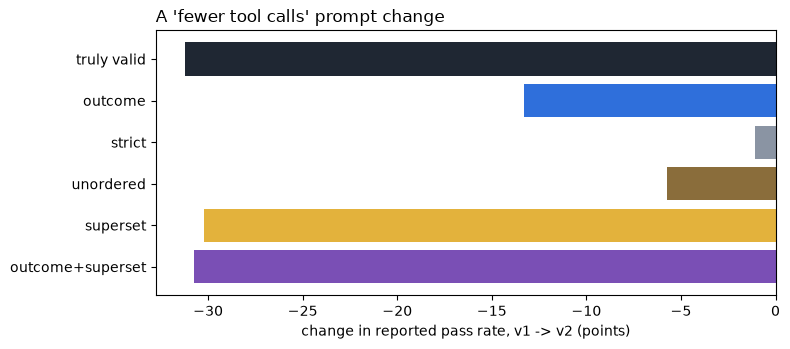

truly valid        -31.2 pts
outcome            -13.3 pts
strict              -1.1 pts
unordered           -5.8 pts
superset           -30.2 pts
outcome+superset   -30.7 pts


In [5]:
v1, v2 = ev["v1 careful"], ev["v2 fewer calls"]
names = ["truly valid"] + list(SCORERS)
d = [v2["p_good"] - v1["p_good"]] + [v2["scorers"][k]["reported"] - v1["scorers"][k]["reported"] for k in SCORERS]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(names[::-1], [x * 100 for x in d][::-1], color=["#7a4fb5", "#e3b23c", "#8a6d3b", "#8a94a3", "#2f6fdb", "#1f2733"])
ax.set_xlabel("change in reported pass rate, v1 -> v2 (points)")
ax.set_title("A 'fewer tool calls' prompt change", loc="left")
plt.tight_layout(); plt.savefig("notebook_chart.png", dpi=120); plt.show()
for n, x in zip(names, d):
    print(f"{n:<17} {x * 100:+6.1f} pts")

The truly valid rate fell 31 points. Outcome scoring saw 13 of them. Strict reference matching saw 1 -
v2 also stopped doing the harmless things (extra search, reads in the other order) that strict was
failing all along, so the two moves cancel.

## Summary

| claim | what the numbers say |
|---|---|
| "the answer is right, so the run passed" | 35% of v2's right-answer runs broke the path |
| "match the reference trajectory" | strict fails 57% of valid v1 runs and reports -1 pt for a -31 pt change |
| "superset match plus the outcome" | best of the matchers, still passes a quarter of v1's broken runs |
| "write invariants" | the only scorer that encodes order, count and argument; its cost is writing them |

## 5. Try your own

In [6]:
# runs = [(True, True, "lookup_order:A17;check_policy;issue_refund:A17"),
#         (True, True, "issue_refund:A17;lookup_order:A17;check_policy")]   # eligible, answer right, steps
# res = audit(runs)
# print(res["good"], res["scorers"]["outcome"], dict(res["hidden"]))
print("uncomment to explore")

uncomment to explore


---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](llmops-genai-platform/agent-trajectory-eval)

Streamlit version, where you paste your own runs:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Sibling builds: [`model-migration-diff`](../model-migration-diff) shows an unchanged score hiding churn;
[`agent-eval-dashboard`](../../ai-agent-workshop/agent-eval-dashboard) is the outcome-pass-rate dashboard this
build audits.